In [7]:
import pandas as pd

url = "https://www.sharkattackfile.net/spreadsheets/GSAF5.xls"

df = pd.read_excel(url)

df = df.drop(columns= ["Time", "Unnamed: 21", "Unnamed: 22", "Name", "href", "Case Number", "Case Number.1", "original order", "href formula", "pdf", "Source", "Species ", "Injury", "Sex"])

percentage_missing = (df.isnull().sum() / len(df) * 100).round(2)

df.drop_duplicates(inplace=True)

df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())

df

,Date,Year,Type,Country,State,Location,Activity,Age,Fatal Y/N
0,18th March,2026.0,Unprovoked,USA,California,Big River Beach Mendocino County,Surfing,39,N
1,14th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Swimming,?,N
2,10th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Wing Foiling,?,N
3,5th March,2026.0,Unprovoked,Australia,Queensland,Lady Elliott Island,Snorkeling,50's,N
4,22nd February,2026.0,Unprovoked,New Caledonia,Noumea,Anse Vata near Point Magnin,Wing Foiling,55,Y
...,...,...,...,...,...,...,...,...,...
7077,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Roebuck Bay,Diving,NaN,Y
7078,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,NaN,Pearl diving,NaN,Y
7079,1900-1905,0.0,Unprovoked,USA,North Carolina,Ocracoke Inlet,Swimming,NaN,Y
7080,1883-1889,0.0,Unprovoked,PANAMA,NaN,"Panama Bay 8ºN, 79ºW",NaN,NaN,Y


In [8]:
df["Country"] = df["Country"].str.strip().str.lower().copy()

df["Fatal Y/N"] = df["Fatal Y/N"].str.strip().str.upper().copy()

df["Fatal Y/N"] = df["Fatal Y/N"].replace({"Y X 2":"Y"}).copy()

df = df[df["Fatal Y/N"].isin(["Y", "N"])].copy()

df

,Date,Year,Type,Country,State,Location,Activity,Age,Fatal Y/N
0,18th March,2026.0,Unprovoked,usa,California,Big River Beach Mendocino County,Surfing,39,N
1,14th March,2026.0,Unprovoked,australia,Western Australia,Exmouth,Swimming,?,N
2,10th March,2026.0,Unprovoked,australia,Western Australia,Exmouth,Wing Foiling,?,N
3,5th March,2026.0,Unprovoked,australia,Queensland,Lady Elliott Island,Snorkeling,50's,N
4,22nd February,2026.0,Unprovoked,new caledonia,Noumea,Anse Vata near Point Magnin,Wing Foiling,55,Y
...,...,...,...,...,...,...,...,...,...
7077,Before 1903,0.0,Unprovoked,australia,Western Australia,Roebuck Bay,Diving,NaN,Y
7078,Before 1903,0.0,Unprovoked,australia,Western Australia,NaN,Pearl diving,NaN,Y
7079,1900-1905,0.0,Unprovoked,usa,North Carolina,Ocracoke Inlet,Swimming,NaN,Y
7080,1883-1889,0.0,Unprovoked,panama,NaN,"Panama Bay 8ºN, 79ºW",NaN,NaN,Y


In [ ]:
df["Type"] = df["Type"].str.strip().str.upper()

df = df[df["Type"].isin(["UNPROVOKED", "PROVOKED"])]

df["Type"].value_counts()



Type
UNPROVOKED    5127
PROVOKED       633
Name: count, dtype: int64

In [ ]:
#New dataframe created to answer H2
h2_df = df[["Country", "Fatal Y/N", "Type"]].copy()

h2_df.shape

(5760, 3)

In [ ]:
#Transformed Fatal column in integer type in order to sum data
h2_df["Is_Fatal"] = (h2_df["Fatal Y/N"] == "Y").astype(int)

group_country = h2_df.groupby("Country").size()

group_country.sort_values(ascending=False)

Country
usa                  2221
australia            1219
south africa          470
bahamas               125
papua new guinea      123
                     ... 
morocco                 1
montenegro              1
monaco                  1
colombia                1
admiralty islands       1
Length: 189, dtype: int64

In [ ]:
#Group by country and aggregated the total number of incidents and total number of fatal incidents
summary = (h2_df.groupby("Country").agg(total_incidents=("Is_Fatal", "size"), fatal_incidents=("Is_Fatal" , sum))).copy()

summary.sort_values("fatal_incidents", ascending=False)

#Created a new column to measure fatality rate %
summary["fatality_rate (%)"] = ((summary["fatal_incidents"] / summary["total_incidents"]) * 100).round(1)

summary = summary[summary["total_incidents"] >= 20]

summary.sort_values("total_incidents", ascending=False)




/var/folders/5r/56m82rjn5cqdmz3b771c5t8c0000gn/T/ipykernel_59412/1758286756.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  summary = (h2_df.groupby("Country").agg(total_incidents=("Is_Fatal", "size"), fatal_incidents=("Is_Fatal" , sum))).copy()


,total_incidents,fatal_incidents,fatality_rate (%)
Country,,,
usa,2221,176,7.9
australia,1219,287,23.5
south africa,470,103,21.9
bahamas,125,11,8.8
papua new guinea,123,54,43.9
new zealand,115,26,22.6
brazil,102,35,34.3
mexico,86,44,51.2
fiji,63,22,34.9


In [ ]:
#Created another summary table , grouping by country also , using total incidents, fatal incidents and fatality rate, but now only considering the provoked types

provoked_df = h2_df[h2_df["Type"] == "PROVOKED"]

summary_provoked_df = provoked_df.groupby("Country").agg(total_incidents=("Is_Fatal", "size"), fatal_incidents=("Is_Fatal" , sum)).copy()

summary_provoked_df["fatality_rate"] = ((summary_provoked_df["fatal_incidents"] / summary_provoked_df["total_incidents"]) * 100).round(1)

summary_provoked_df = summary_provoked_df[summary_provoked_df["total_incidents"] >= 5]

summary_provoked_df.sort_values("total_incidents", ascending=False)

/var/folders/5r/56m82rjn5cqdmz3b771c5t8c0000gn/T/ipykernel_59412/2976543576.py:3: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  summary_provoked_df = provoked_df.groupby("Country").agg(total_incidents=("Is_Fatal", "size"), fatal_incidents=("Is_Fatal" , sum)).copy()


,total_incidents,fatal_incidents,fatality_rate
Country,,,
usa,238,4,1.7
australia,142,2,1.4
south africa,58,0,0.0
new zealand,21,0,0.0
bahamas,18,0,0.0
mexico,12,1,8.3
papua new guinea,12,0,0.0
italy,11,1,9.1
england,9,1,11.1


In [ ]:
#Merged both summary tables - the overall with the provoked
merged = summary.merge(summary_provoked_df, left_index=True, right_index=True, how="left", suffixes=("_overall", "_provoked"))

merged.sort_values("total_incidents_overall", ascending=False).head(15)

,total_incidents_overall,fatal_incidents_overall,fatality_rate_overall,total_incidents_provoked,fatal_incidents_provoked,fatality_rate_provoked
Country,,,,,,
usa,2221,176,7.9,238.0,4.0,1.7
australia,1219,287,23.5,142.0,2.0,1.4
south africa,470,103,21.9,58.0,0.0,0.0
bahamas,125,11,8.8,18.0,0.0,0.0
papua new guinea,123,54,43.9,12.0,0.0,0.0
new zealand,115,26,22.6,21.0,0.0,0.0
brazil,102,35,34.3,6.0,1.0,16.7
mexico,86,44,51.2,12.0,1.0,8.3
fiji,63,22,34.9,NaN,NaN,NaN


In [ ]:
#Created the chart data
chart_data = (merged.sort_values("total_incidents_overall", ascending=False).head(15)[["fatality_rate_overall", "fatality_rate_provoked"]])

chart_data

,fatality_rate_overall,fatality_rate_provoked
Country,,
usa,7.9,1.7
australia,23.5,1.4
south africa,21.9,0.0
bahamas,8.8,0.0
papua new guinea,43.9,0.0
new zealand,22.6,0.0
brazil,34.3,16.7
mexico,51.2,8.3
fiji,34.9,NaN


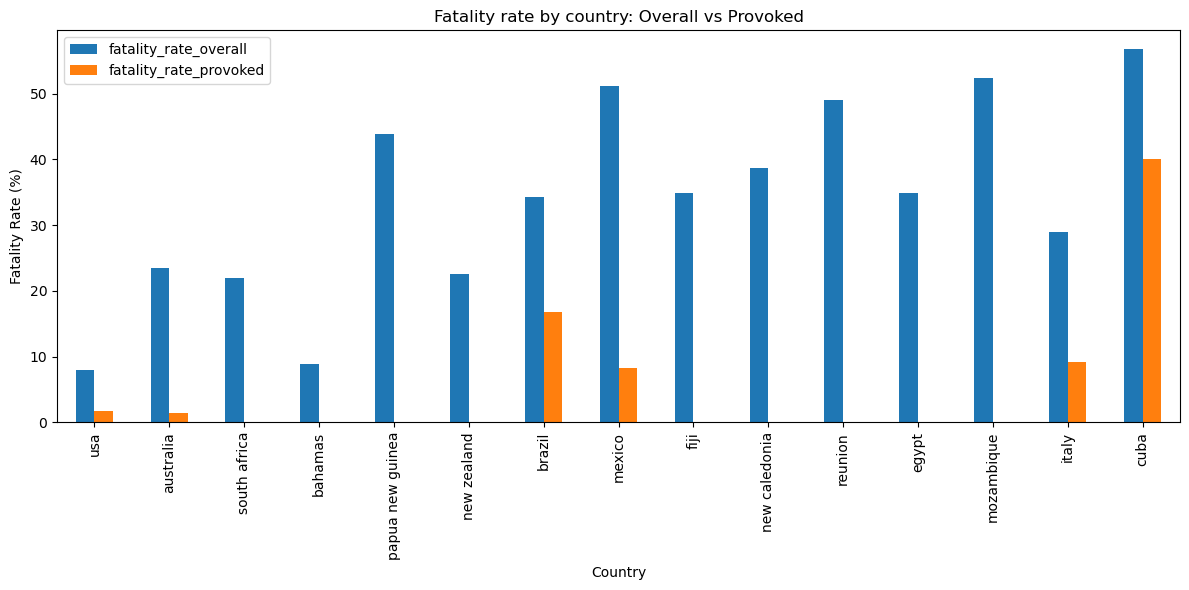

In [71]:
import matplotlib.pyplot as plt

chart_data.plot(kind="bar", figsize=(12, 6), title="Fatality rate by country: Overall vs Provoked", ylabel= "Fatality Rate (%)")

plt.tight_layout()

plt.show()

**H2 — Volume vs fatality rate across countries**


**Findings:**


**High-incident countries are not the same as high-fatality-rate countries.**

USA: 2,221 incidents, 7.9% fatality rate.
Australia: fewer incidents than USA, higher fatality rate.
Papua New Guinea: 123 incidents, 44% fatality rate.

The provoked-incidents prediction was wrong. **Provoked incidents are less fatal than incidents overall, not more.**

USA: drops from 7.9% overall to 1.7% provoked.
Australia: drops from ~15% overall to 1.4% provoked.
Most countries show 0% fatality on provoked incidents.



**Conclusions:**

H2 is partially supported: the volume vs fatality-rate mismatch is real, but the provoked twist goes the opposite way from what was predicted.

Provoked incidents are high-frequency, low-severity. Unprovoked incidents are low-frequency, high-severity.
These are two fundamentally different risk profiles and should not be treated as one.



**Recommendations for insurers:**

- Don't price provoked vs unprovoked differently at the customer level. Even though unprovoked incidents are clearly more fatal, whether a future incident will be provoked isn't knowable when the policy is sold — it's only classifiable after a claim.
- Set prices country by country, not one rate for the whole world. A global average would charge the USA too much and Papua New Guinea too little.
- When setting money aside for rare, expensive payouts, focus on unprovoked attacks in countries where people are more likely to die. That's where the big claims come from.


**To be considered:**
Reporting bias;
Small samples;
Historical data spans centuries.